In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os


# feature_path = os.path.abspath(r"C:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor")
feature_path = os.path.abspath('/Users/alexg/Documents/Documents/Prize-Picks-Prop-Predictor')
if feature_path not in sys.path:
    sys.path.append(feature_path)

from FEATURE_ENGINEERING.features import *
from PROPS_EV.calculateEVS import *
from PROPS_EV.backtest import *

## Load Model and Features

In [9]:
model = joblib.load('Models/xgbModel.pkl')
features = joblib.load('Models/top_features.pkl')

## Load Player Logs Data

In [10]:
pd.set_option('display.max_columns', None)
eplison = 0.000001

s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s25['EXPECTED_USAGE_MIN'] = s25['USG_PCT_ROLLING_AVG_5'] * (s25['MIN_ROLLING_AVG_5'] + eplison)

s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s24['EXPECTED_USAGE_MIN'] = s24['USG_PCT_ROLLING_AVG_5'] * (s24['MIN_ROLLING_AVG_5'] + eplison)

df = pd.concat([s25, s24]).sort_values(by='GAME_DATE')

## Load Odds for Single Bookies

In [11]:
backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/singleBookies.csv')
backtestData = backtestData[(backtestData['ODDS'] <= 200) & (backtestData['ODDS'] >= -200)]
backtestData = backtestData[backtestData['CATEGORY'] == 'points']
backtestData.head()

,NAME,CATEGORY,SIDE,BOOKMAKER,LINE,ODDS,fair_line,fair_odds,GAME_DATE
7,Jesse Edwards,points,over,espnbet,28.5,110,28.5,129,2024-10-23
9,LeBron James,points,under,espnbet,15.5,-140,15.5,-117,2024-10-23
10,LeBron James,points,over,espnbet,15.5,100,15.5,117,2024-10-23
13,Jesse Edwards,points,under,espnbet,28.5,-160,28.5,-129,2024-10-23
14,Jaime Jaquez,points,under,fanduel,15.5,-125,11.5,100,2024-10-23


## Single game backtest for single bets

In [12]:
results = backtestSingle(df, backtestData, '2024-12-31')

# Calculate metrics
if not results.empty:
    # Overall metrics
    total_bets = len(results)
    total_wins = results['won'].sum()
    win_rate = results['won'].mean()
    
    # Metrics for recommended bets only
    recommended = results[results['recommendation'] == 1]
    if not recommended.empty:
        rec_total = len(recommended)
        rec_wins = recommended['won'].sum()
        rec_win_rate = recommended['won'].mean()
        
        print(f"\n--- All Bets ---")
        print(f"Total: {total_bets}, Wins: {total_wins}, Win Rate: {win_rate:.2%}")
        print(f"\n--- Recommended Bets (Edge > 4.5) ---")
        print(f"Total: {rec_total}, Wins: {rec_wins}, Win Rate: {rec_win_rate:.2%}")
results

Processing single bets...

--- All Bets ---
Total: 10, Wins: 5, Win Rate: 50.00%

--- Recommended Bets (Edge > 4.5) ---
Total: 8, Wins: 4, Win Rate: 50.00%


,player,bookmaker,side,line,odds,pred,actual,edge,recommendation,won,date
0,Shai Gilgeous-Alexander,draftkings,under,39.5,110,27.062998,40,-12.437002,1,0,2024-12-31
1,Shai Gilgeous-Alexander,espnbet,under,39.5,-110,27.062998,40,-12.437002,1,0,2024-12-31
2,Payton Pritchard,draftkings,under,19.5,-115,10.262538,19,-9.237462,1,1,2024-12-31
3,Jakob Poeltl,draftkings,over,7.5,110,10.855179,7,3.355179,0,0,2024-12-31
4,Jalen Williams,draftkings,over,13.5,-125,22.493866,14,8.993866,1,1,2024-12-31
5,Austin Reaves,fanduel,under,34.5,-174,21.983374,35,-12.516626,1,0,2024-12-31
6,De'Aaron Fox,espnbet,under,31.5,-160,17.513828,33,-13.986172,1,0,2024-12-31
7,Sam Hauser,draftkings,under,12.5,-140,6.635249,12,-5.864751,1,1,2024-12-31
8,Scottie Barnes,draftkings,under,16.5,-105,12.320035,16,-4.179965,0,1,2024-12-31
9,Davion Mitchell,draftkings,under,9.5,-160,4.617381,9,-4.882619,1,1,2024-12-31


## Grabs all dates in playerlogs to backtest full year

In [6]:
uniqueDates = sorted(s25['GAME_DATE'].unique())
all_results = []

for i, date in enumerate(uniqueDates, 1):
    print(f"Processing {date}... {i}/{len(uniqueDates)}")
    
    try:
        date_results = backtestSingle(df, backtestData, date, edge_threshold=4.5, top_n=3)
        
        if not date_results.empty:
            all_results.append(date_results)
            print(f"  ✓ Processed {len(date_results)} bets")
        else:
            print(f"  No results for {date}")
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        continue

# Combine all results
if all_results:
    final_results = pd.concat(all_results, ignore_index=True)
    print(f"\n✓ Complete! Total bets analyzed: {len(final_results)}")



Processing 2024-10-22... 1/163
No bets found for 2024-10-22
  No results for 2024-10-22
Processing 2024-10-23... 2/163
Processing single bets...
  ✓ Processed 3 bets
Processing 2024-10-24... 3/163
Processing single bets...
  ✓ Processed 3 bets
Processing 2024-10-25... 4/163
Processing single bets...
  ✓ Processed 3 bets
Processing 2024-10-26... 5/163
Processing single bets...
  ✓ Processed 3 bets
Processing 2024-10-27... 6/163
Processing single bets...
  ✓ Processed 3 bets
Processing 2024-10-28... 7/163
Processing single bets...
  ✓ Processed 3 bets
Processing 2024-10-29... 8/163
Processing single bets...
  ✓ Processed 3 bets
Processing 2024-10-30... 9/163
Processing single bets...
  ✓ Processed 3 bets
Processing 2024-10-31... 10/163
Processing single bets...
  ✓ Processed 3 bets
Processing 2024-11-01... 11/163
Processing single bets...
  ✓ Processed 3 bets
Processing 2024-11-02... 12/163
Processing single bets...
  ✓ Processed 3 bets
Processing 2024-11-03... 13/163
Processing single b

           COMPREHENSIVE BETTING ANALYSIS

 ALL BETS ANALYSIS:
   Total Bets: 480
   Wins: 275
   Hit Rate: 57.29%
   Total Profit: $537.26
   Total Staked: $2,400.00
   ROI: 22.39%
   Volatility: $10.14
   Max Drawdown: $-64.23
   Sharpe Ratio: 5.259

 RECOMMENDED BETS ANALYSIS (Edge > 4.5):
   Total Bets: 399
   Wins: 241
   Hit Rate: 60.40%
   Total Profit: $544.72
   Total Staked: $1,995.00
   ROI: 27.30%
   Volatility: $8.89
   Max Drawdown: $-40.50
   Sharpe Ratio: 6.194


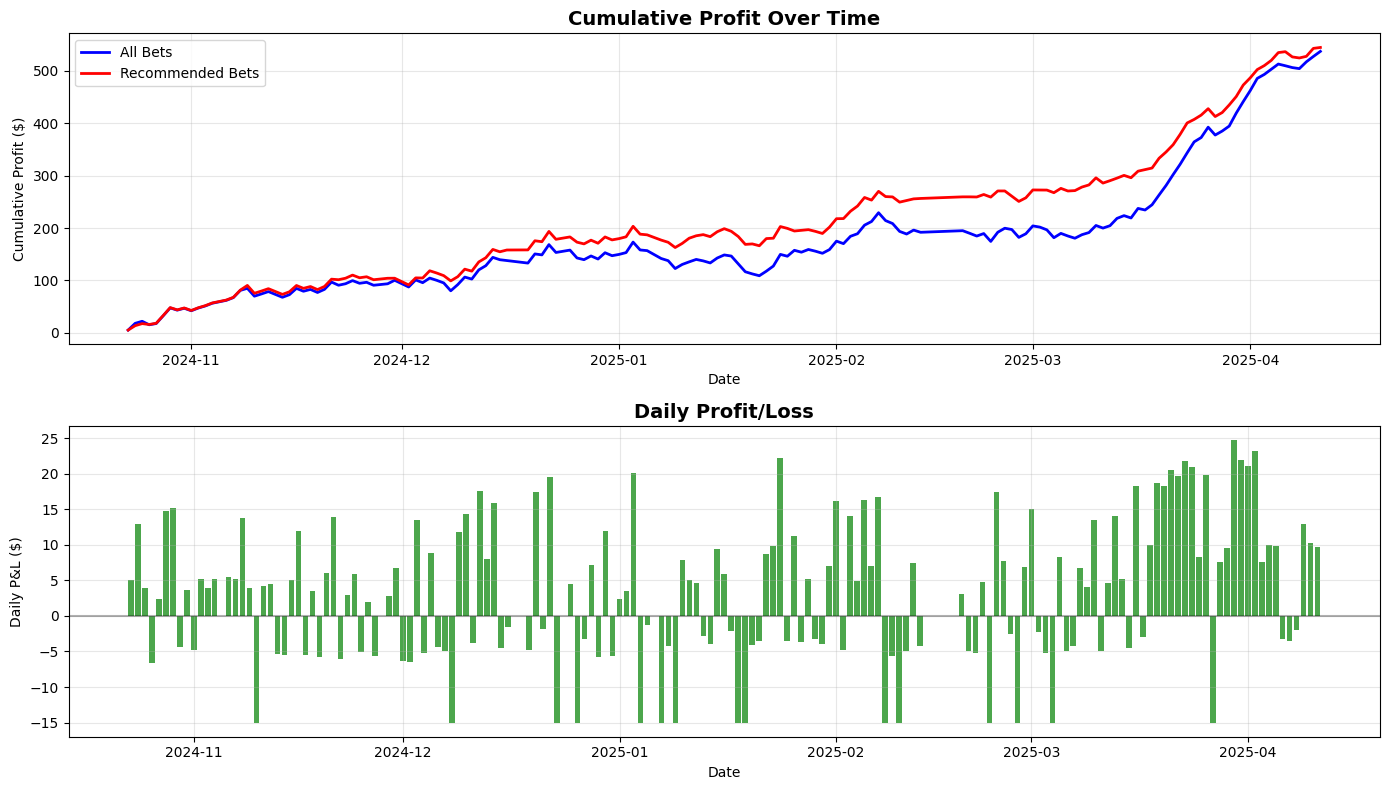

In [6]:
final_results = pd.read_csv('backtestSinglesTop3.csv')

# Calculate metrics for all bets
all_metrics = calculate_advanced_metrics(final_results)

# Calculate metrics for recommended bets only
recommended = final_results[final_results['recommendation'] == 1]
rec_metrics = calculate_advanced_metrics(recommended)

# Display comprehensive results
print("=" * 60)
print("           COMPREHENSIVE BETTING ANALYSIS")
print("=" * 60)

if all_metrics:
    print(f"\n ALL BETS ANALYSIS:")
    print(f"   Total Bets: {all_metrics['total_bets']:,}")
    print(f"   Wins: {all_metrics['total_wins']:,}")
    print(f"   Hit Rate: {all_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${all_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${all_metrics['total_staked']:,.2f}")
    print(f"   ROI: {all_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${all_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${all_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {all_metrics['sharpe_ratio']:.3f}")

if rec_metrics:
    print(f"\n RECOMMENDED BETS ANALYSIS (Edge > 4.5):")
    print(f"   Total Bets: {rec_metrics['total_bets']:,}")
    print(f"   Wins: {rec_metrics['total_wins']:,}")
    print(f"   Hit Rate: {rec_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${rec_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${rec_metrics['total_staked']:,.2f}")
    print(f"   ROI: {rec_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${rec_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${rec_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {rec_metrics['sharpe_ratio']:.3f}")

# Plots cumulative profit over time
if all_metrics and not all_metrics['daily_pnl'].empty:
    plt.figure(figsize=(14, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['cumulative_profit'], 
             linewidth=2, label='All Bets', color='blue')
    if rec_metrics and not rec_metrics['daily_pnl'].empty:
        plt.plot(rec_metrics['daily_pnl']['date'], rec_metrics['daily_pnl']['cumulative_profit'], 
                 linewidth=2, label='Recommended Bets', color='red')
    plt.title('Cumulative Profit Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Profit ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.bar(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['profit'], 
            alpha=0.7, label='Daily P&L', color='green')
    plt.title('Daily Profit/Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Daily P&L ($)')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()